<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/Projeto_Final_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome:** Kauã de Oliveira Ribeiro, Lívia Vilela Ribeiro Guimarães e João Gabriel Ferreira Ribeiro

## **BER teórica das diferentes modulações digitais**

Um dos parâmetros mais importantes para avaliar o desempenho de sistemas de comunicação digital é a taxa de erro de bit, denominada BER (*Bit Error Rate*). Essa grandeza representa a probabilidade de um bit ser detectado incorretamente na recepção.

Em canais AWGN (*Additive White Gaussian Noise*), é possível analisar a BER teórica em função da relação entre a energia média por bit e a densidade espectral de potência do ruído:

$$
\frac{E_b}{N_0}
$$

As expressões de probabilidade de erro são frequentemente escritas utilizando a função $Q(x)$, definida como a probabilidade de uma variável aleatória gaussiana padronizada exceder determinado valor. Entretanto, em simulações computacionais, é comum utilizar a função complementar do erro, `erfc()`, disponível diretamente em bibliotecas matemáticas do Python. A relação entre essas funções é dada por:

$$
Q(x)=
\frac{1}{2}
\operatorname{erfc}
\left(
\frac{x}{\sqrt{2}}
\right)
$$

Outro aspecto importante das modulações digitais multiníveis é a influência do número de símbolos da constelação, representado por $M$. Cada símbolo transporta k bits de informação:

$$
k=\log_2(M)
$$

O aumento de $M$ permite transmitir mais bits por símbolo, o que consequentemente aumenta a eficiência espectral, permitindo transmitir mais informação em uma mesma largura de banda. Entretanto, seus efeitos dependem da família de modulação analisada. Nas modulações M-PSK e M-QAM, a elevação de $M$ normalmente reduz a separação entre os símbolos, aumentando a sensibilidade ao ruído. Na M-FSK ortogonal, o aumento de $M$ pode melhorar a eficiência de potência, mas exige maior largura de banda.

---

### **Modulação M-PSK**

Na modulação M-PSK (*M-ary Phase Shift Keying*), a informação é transmitida utilizando $M$ fases distintas. O aumento de $M$ reduz a separação angular entre símbolos vizinhos, tornando o sistema mais sensível ao ruído.

Para codificação Gray, $M \geq 4$ e valores elevados de $E_b/N_0$, a BER pode ser aproximada por:

$$
P_b
\approx
\frac{2}{\log_2(M)}
Q
\left(
\sqrt{
2\log_2(M)
\frac{E_b}{N_0}
}
\sin
\left(
\frac{\pi}{M}
\right)
\right)
$$

Utilizando `erfc()`:

$$
P_b
\approx
\frac{1}{\log_2(M)}
\operatorname{erfc}
\left(
\sqrt{
\log_2(M)
\frac{E_b}{N_0}
}
\sin
\left(
\frac{\pi}{M}
\right)
\right)
$$

---

### **Modulação M-QAM com constelação quadrada**

Na modulação M-QAM (*M-ary Quadrature Amplitude Modulation*), os símbolos são representados por diferentes combinações de amplitude e fase. Essa técnica apresenta elevada eficiência espectral e é empregada em diversos sistemas modernos de comunicação.

Quando $k=\log_2(M)$ é par, é possível formar uma constelação quadrada com:

$$
L=\sqrt{M}
$$

níveis em cada eixo. Alguns exemplos são 4-QAM, 16-QAM, 64-QAM e 256-QAM.

Para constelações quadradas com mapeamento Gray e valores elevados de $E_b/N_0$, a BER pode ser aproximada por:

$$
P_b
\approx
\frac{4}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{M}}
\right)
Q
\left(
\sqrt{
\frac{3\log_2(M)}{M-1}
\frac{E_b}{N_0}
}
\right)
$$

Utilizando `erfc()`:

$$
P_b
\approx
\frac{2}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{3\log_2(M)}
{2(M-1)}
\frac{E_b}{N_0}
}
\right)
$$

---

### **Modulação M-QAM com constelação não quadrada**

Quando $k=\log_2(M)$ é ímpar, não é possível dividir igualmente os bits entre os eixos em fase e em quadratura. Consequentemente, a constelação não pode ser formada pelo produto cartesiano de duas constelações PAM unidimensionais.

Alguns exemplos são:

$$
8\text{-QAM},\quad
32\text{-QAM},\quad
128\text{-QAM},\quad
512\text{-QAM}
$$

Uma possibilidade consiste em utilizar uma constelação cruzada, também chamada *cross constellation*.

Para constelações M-QAM cruzadas e valores elevados de $E_b/N_0$, a probabilidade de erro de símbolo pode ser aproximada por:

$$
P_s
\approx
2
\left(
1-\frac{1}{\sqrt{2M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{
96\log_2(M)
}{
62M-64
}
\frac{E_b}{N_0}
}
\right)
$$

Diferentemente do caso quadrado, não é possível garantir mapeamento Gray completo entre todos os símbolos vizinhos mais próximos. Portanto, a BER não é exatamente igual à SER dividida pela quantidade de bits por símbolo. Para constelações cruzadas:

$$
P_b >
\frac{P_s}{\log_2(M)}
$$

Ainda assim, a expressão:

$$
P_{b,\text{ref}}
=\frac{P_s}{\log_2(M)}
$$

pode ser utilizada como uma curva de referência inferior para comparação com a BER simulada:

$$
P_{b,\text{ref}}
\approx
\frac{2}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{2M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{
96\log_2(M)
}{
62M-64
}
\frac{E_b}{N_0}
}
\right)
$$

Uma estimativa mais precisa da BER depende da geometria da constelação e do mapeamento entre os grupos de bits e os símbolos.

---

### **Modulação M-FSK coerente**

Na modulação M-FSK (*M-ary Frequency Shift Keying*), cada símbolo é associado a uma frequência distinta. O aumento do número de frequências pode melhorar a imunidade ao ruído, mas exige maior largura de banda.

Para sinais ortogonais com detecção coerente em canais AWGN, a probabilidade de erro de símbolo pode ser aproximada por:

$$
P_s
\approx
(M-1)
Q
\left(
\sqrt{
\log_2(M)
\frac{E_b}{N_0}
}
\right)
$$

Utilizando `erfc()`:

$$
P_s
\approx
\frac{M-1}{2}
\operatorname{erfc}
\left(
\sqrt{
\frac{
\log_2(M)
}{2}
\frac{E_b}{N_0}
}
\right)
$$

Para a M-FSK ortogonal, a relação entre BER e SER é dada por:

$$
P_b=
\frac{M}{2(M-1)}
P_s
$$

Portanto:

$$
P_b
\approx
\frac{M}{4}
\operatorname{erfc}
\left(
\sqrt{
\frac{
\log_2(M)
}{2}
\frac{E_b}{N_0}
}
\right)
$$

Nesse caso, a relação independe do mapeamento entre os símbolos e os bits, pois a distância euclidiana é a mesma entre todos os pares de símbolos ortogonais.

Em todos os casos, a substituição da função $Q(x)$ pela função `erfc()` permite implementar diretamente as expressões teóricas em Python, simplificando o cálculo das curvas e a comparação com os resultados simulados.

**Referências**

[1] Guimarães, D. A.; Souza, R. A. A. *Transmissão Digital: Princípios e Aplicações*. São Paulo: Editora Érica, 2014.

[2] Guimarães, D. A. *Digital Transmission: A Simulation-Aided Introduction with VisSim/Comm*. Springer, 2010.

In [1]:
# Importando as bilbiotecas necessárias
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.special import erfc

In [2]:
# Criando as funções auxiliares

# Converte inteiros em código Gray para inteiros binários
def gray_to_binary(gray):
    binary = gray.copy()
    shift = 1

    while True:
        shifted = binary >> shift

        if np.all(shifted == 0):
            break

        binary = binary ^ shifted
        shift <<= 1

    return binary

# Converte grupos de k bits para números decimais
def bits_to_decimal(bits_grouped):
    k = bits_grouped.shape[1]
    weights = 1 << np.arange(k - 1, -1, -1)

    return bits_grouped.dot(weights)

# Converte números decimais para grupos de k bits
def decimal_to_bits(decimal_values, k):
    return (
        ((decimal_values[:, None] & (1 << np.arange(k - 1, -1, -1))) > 0)
        .astype(int)
    )

In [3]:
# Definindo os parâmetros das simulações

M_list = [2, 4, 8, 16, 32, 64]      # Ordens das modulações
N_bits = 1000000                    # Número total de bits simulados
EbN0dB_range = np.arange(0, 20)     # Intervalo de Eb/N0 de 0 a 19 dB
itr = len(EbN0dB_range)             # Número total de valores de Eb/N0 testados

# Valores calculados para análise final
ber_psk_theo_all = {}
ber_qam_theo_all = {}
ber_fsk_theo_all = {}
ber_psk_sim_all = {}
ber_qam_sim_all = {}
ber_fsk_sim_all = {}

In [4]:
# ------------------------------------------------------------
# Funções auxiliares para nomear corretamente as modulações
# ------------------------------------------------------------

def nome_psk(M):
    return "BPSK" if M == 2 else "QPSK" if M==4 else f"{M}-PSK"

def nome_qam(M):
    return f"{M}-QAM"


def nome_fsk(M):
    return "BFSK" if M == 2 else "QFSK" if M==4 else f"{M}-FSK"

## **Simulação de BER para M-PSK**

BPSK   | Eb/N0 =  0 dB | BER_sim = 7.869300e-02 | BER_teo = 7.864960e-02
BPSK   | Eb/N0 =  1 dB | BER_sim = 5.595300e-02 | BER_teo = 5.628195e-02
BPSK   | Eb/N0 =  2 dB | BER_sim = 3.730300e-02 | BER_teo = 3.750613e-02
BPSK   | Eb/N0 =  3 dB | BER_sim = 2.270500e-02 | BER_teo = 2.287841e-02
BPSK   | Eb/N0 =  4 dB | BER_sim = 1.246000e-02 | BER_teo = 1.250082e-02
BPSK   | Eb/N0 =  5 dB | BER_sim = 5.924000e-03 | BER_teo = 5.953867e-03
BPSK   | Eb/N0 =  6 dB | BER_sim = 2.396000e-03 | BER_teo = 2.388291e-03
BPSK   | Eb/N0 =  7 dB | BER_sim = 8.320000e-04 | BER_teo = 7.726748e-04
BPSK   | Eb/N0 =  8 dB | BER_sim = 1.800000e-04 | BER_teo = 1.909078e-04
BPSK   | Eb/N0 =  9 dB | BER_sim = 3.200000e-05 | BER_teo = 3.362723e-05
BPSK   | Eb/N0 = 10 dB | BER_sim = 2.000000e-06 | BER_teo = 3.872108e-06
BPSK   | Eb/N0 = 11 dB | BER_sim = 0.000000e+00 | BER_teo = 2.613068e-07
BPSK   | Eb/N0 = 12 dB | BER_sim = 0.000000e+00 | BER_teo = 9.006010e-09
BPSK   | Eb/N0 = 13 dB | BER_sim = 0.000000e+00 | B

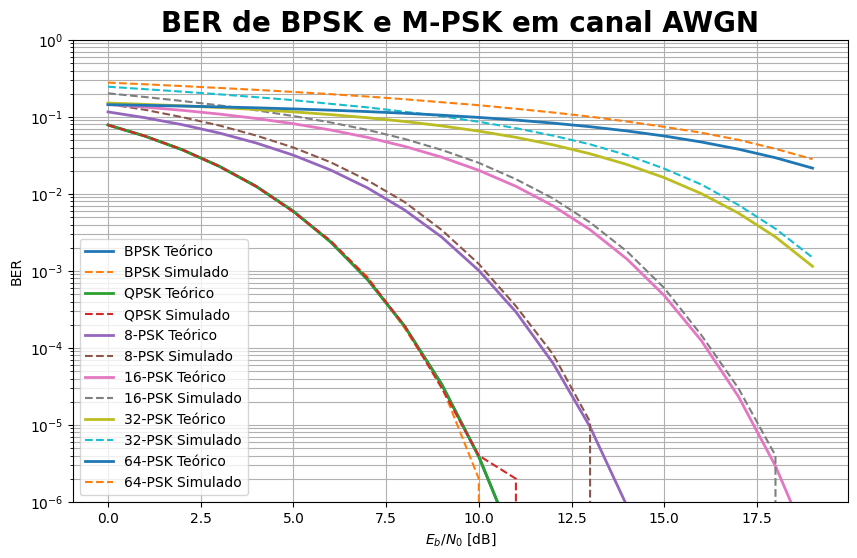

In [5]:
# -----------------------------
# Figura
# -----------------------------

plt.figure(figsize=(10, 6))


# -----------------------------
# Loop para cada modulação
# -----------------------------

for M in M_list:

    k = int(np.log2(M))

    N_symbols = N_bits // k
    N_bits_real = N_symbols * k

    ber_sim = np.zeros(itr)
    ber_theo = np.zeros(itr)

    modulation_name = nome_psk(M)

    # ========================================================
    # Caso especial: BPSK
    # ========================================================

    if M == 2:

        # ----------------------------------------------------
        # 1) Geração dos bits
        # ----------------------------------------------------

        tx_bits = np.random.randint(
            0,
            2,
            N_bits_real
        )

        # ----------------------------------------------------
        # 2) Mapeamento BPSK
        # ----------------------------------------------------
        #
        # bit 0 -> -1
        # bit 1 -> +1

        tx_symbols = 2 * tx_bits - 1

        # ----------------------------------------------------
        # 3) Loop de Eb/N0
        # ----------------------------------------------------

        for n, EbN0dB in enumerate(EbN0dB_range):

            # Conversão de dB para escala linear
            EbN0 = 10 ** (
                EbN0dB / 10
            )

            # Como Eb = 1:
            #
            # N0 = 1 / (Eb/N0)
            #
            # Variância do AWGN:
            #
            # sigma² = N0 / 2
            #
            # Desvio-padrão:
            #
            # sigma = 1 / sqrt(2 * Eb/N0)

            noise_std = 1 / np.sqrt(
                2 * EbN0
            )

            # Ruído AWGN real
            noise = noise_std * np.random.randn(
                N_bits_real
            )

            # Sinal recebido
            rx_symbols = tx_symbols + noise

            # ------------------------------------------------
            # Detector BPSK
            # ------------------------------------------------
            #
            # rx >= 0 -> bit 1
            # rx <  0 -> bit 0

            rx_bits = (
                rx_symbols >= 0
            ).astype(int)

            # ------------------------------------------------
            # BER simulada
            # ------------------------------------------------

            bit_errors = np.sum(
                tx_bits != rx_bits
            )

            ber_sim[n] = (
                bit_errors /
                N_bits_real
            )

            # ------------------------------------------------
            # BER teórica exata da BPSK
            # ------------------------------------------------
            #
            # BER = 0.5 * erfc(sqrt(Eb/N0))

            ber_theo[n] = 0.5 * erfc(
                np.sqrt(EbN0)
            )

            print(
                f"{modulation_name:6s} | "
                f"Eb/N0 = {EbN0dB:2d} dB | "
                f"BER_sim = {ber_sim[n]:.6e} | "
                f"BER_teo = {ber_theo[n]:.6e}"
            )

    # ========================================================
    # Caso geral: M-PSK com M >= 4
    # ========================================================

    else:

        # ----------------------------------------------------
        # 1) Geração dos bits
        # ----------------------------------------------------

        tx_bits = np.random.randint(
            0,
            2,
            N_bits_real
        )

        # Agrupamento em símbolos de k bits
        tx_bits_grouped = tx_bits.reshape(
            (N_symbols, k)
        )

        # Conversão binário -> decimal
        tx_decimal = bits_to_decimal(
            tx_bits_grouped
        )

        # ----------------------------------------------------
        # 2) Mapeamento Gray
        # ----------------------------------------------------

        tx_gray = (
            tx_decimal ^
            (tx_decimal >> 1)
        )

        # ----------------------------------------------------
        # 3) Constelação M-PSK
        # ----------------------------------------------------

        Eb = 1
        Es = k * Eb

        constellation = np.zeros(
            (M, 2)
        )

        for i in range(M):

            theta_i = (
                2 * np.pi * i / M
            )

            constellation[i, 0] = (
                np.sqrt(Es) *
                np.cos(theta_i)
            )

            constellation[i, 1] = (
                np.sqrt(Es) *
                np.sin(theta_i)
            )

        # Símbolos transmitidos
        tx_symbols = constellation[
            tx_gray
        ]

        # ----------------------------------------------------
        # 4) Loop de Eb/N0
        # ----------------------------------------------------

        for n, EbN0dB in enumerate(EbN0dB_range):

            # Conversão para escala linear
            EbN0 = 10 ** (
                EbN0dB / 10
            )

            # Como Eb = 1:
            #
            # N0 = Eb / (Eb/N0)

            N0 = Eb / EbN0

            # Desvio-padrão em cada eixo
            noise_std = np.sqrt(
                N0 / 2
            )

            # Ruído nos eixos I e Q
            noise = noise_std * np.random.randn(
                N_symbols,
                2
            )

            # Canal AWGN
            rx_symbols = (
                tx_symbols +
                noise
            )

            # ------------------------------------------------
            # Detector de máxima verossimilhança
            # ------------------------------------------------

            distances = np.zeros(
                (N_symbols, M)
            )

            for i in range(M):

                distances[:, i] = np.sum(
                    (
                        rx_symbols -
                        constellation[i]
                    ) ** 2,
                    axis=1
                )

            # Índice Gray detectado
            rx_gray = np.argmin(
                distances,
                axis=1
            )

            # Decodificação Gray
            rx_decimal = gray_to_binary(
                rx_gray
            )

            # Conversão decimal -> bits
            rx_bits_grouped = decimal_to_bits(
                rx_decimal,
                k
            )

            rx_bits = rx_bits_grouped.reshape(
                -1
            )

            # ------------------------------------------------
            # BER simulada
            # ------------------------------------------------

            bit_errors = np.sum(
                tx_bits != rx_bits
            )

            ber_sim[n] = (
                bit_errors /
                N_bits_real
            )

            # ------------------------------------------------
            # BER teórica aproximada para M-PSK com Gray
            # ------------------------------------------------

            ber_theo[n] = (
                (1 / k) *
                erfc(
                    np.sqrt(k * EbN0) *
                    np.sin(np.pi / M)
                )
            )

            print(
                f"{modulation_name:6s} | "
                f"Eb/N0 = {EbN0dB:2d} dB | "
                f"BER_sim = {ber_sim[n]:.6e} | "
                f"BER_teo = {ber_theo[n]:.6e}"
            )

    # --------------------------------------------------------
    # Armazenamento das curvas
    # --------------------------------------------------------

    ber_psk_theo_all[M] = (
        ber_theo.copy()
    )

    ber_psk_sim_all[M] = (
        ber_sim.copy()
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        linewidth=2,
        label=f"{modulation_name} Teórico"
    )

    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        linestyle="--",
        label=f"{modulation_name} Simulado"
    )


# -----------------------------
# Configuração do gráfico
# -----------------------------

plt.grid(True, which="both")
plt.xlabel("$E_b/N_0$ [dB]")
plt.ylabel("BER")
plt.title("BER de BPSK e M-PSK em canal AWGN", fontsize=20, fontweight="bold")
plt.legend()
plt.ylim(1e-6, 1)
plt.show()

## **Simulação de BER para M-QAM**

M =  2 | Eb/N0 =  0 dB | BER_sim = 7.904100e-02 | BER_teo = 7.864960e-02
M =  2 | Eb/N0 =  1 dB | BER_sim = 5.615700e-02 | BER_teo = 5.628195e-02
M =  2 | Eb/N0 =  2 dB | BER_sim = 3.770500e-02 | BER_teo = 3.750613e-02
M =  2 | Eb/N0 =  3 dB | BER_sim = 2.281700e-02 | BER_teo = 2.287841e-02
M =  2 | Eb/N0 =  4 dB | BER_sim = 1.236100e-02 | BER_teo = 1.250082e-02
M =  2 | Eb/N0 =  5 dB | BER_sim = 5.905000e-03 | BER_teo = 5.953867e-03
M =  2 | Eb/N0 =  6 dB | BER_sim = 2.360000e-03 | BER_teo = 2.388291e-03
M =  2 | Eb/N0 =  7 dB | BER_sim = 8.060000e-04 | BER_teo = 7.726748e-04
M =  2 | Eb/N0 =  8 dB | BER_sim = 2.070000e-04 | BER_teo = 1.909078e-04
M =  2 | Eb/N0 =  9 dB | BER_sim = 2.400000e-05 | BER_teo = 3.362723e-05
M =  2 | Eb/N0 = 10 dB | BER_sim = 2.000000e-06 | BER_teo = 3.872108e-06
M =  2 | Eb/N0 = 11 dB | BER_sim = 0.000000e+00 | BER_teo = 2.613068e-07
M =  2 | Eb/N0 = 12 dB | BER_sim = 0.000000e+00 | BER_teo = 9.006010e-09
M =  2 | Eb/N0 = 13 dB | BER_sim = 0.000000e+00 | B

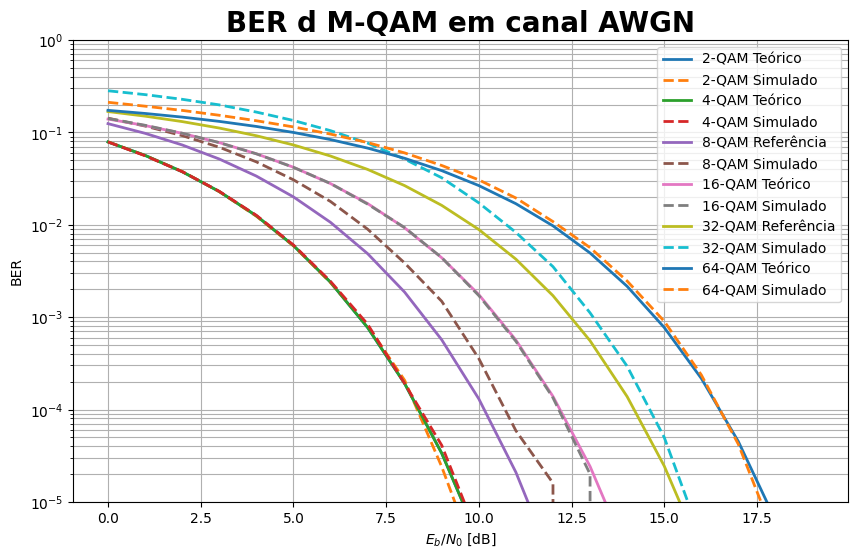

In [6]:
# ============================================================
#   Simulação de BER para 2-QAM e M-QAM em canal AWGN
#
#   Cada símbolo é representado por um vetor bidimensional:
#
#       s_i = [I_i, Q_i]
#
#   em que:
#       I_i -> componente em fase
#       Q_i -> componente em quadratura
#
#   O receptor utiliza o critério de máxima verossimilhança:
#   escolhe o ponto da constelação com menor distância
#   euclidiana em relação ao vetor recebido.
#
#   São considerados os seguintes casos:
#
#   1) 2-QAM:
#      Equivalente à modulação BPSK.
#
#   2) M-QAM quadrada:
#      k = log2(M) par
#      Exemplos: 4-QAM, 16-QAM e 64-QAM.
#
#   3) M-QAM não quadrada:
#      k = log2(M) ímpar
#      Exemplos: 8-QAM e 32-QAM cruzada.
# ============================================================


# ------------------------------------------------------------
# Inclui automaticamente a modulação 2-QAM na lista
# sem alterar a lista original utilizada em outras células.
# ------------------------------------------------------------

M_list_qam = sorted(set([2] + list(M_list)))


# -----------------------------
# Figura
# -----------------------------

plt.figure(figsize=(10, 6))


# -----------------------------
# Loop para cada M-QAM
# -----------------------------

for M in M_list_qam:

    # Quantidade de bits transportados por símbolo
    k = int(np.log2(M))

    # Número de símbolos simulados
    N_symbols = N_bits // k

    # Ajuste para garantir que a quantidade de bits
    # seja um múltiplo inteiro de k
    N_bits_real = N_symbols * k

    # Energia média por bit
    Eb = 1

    # Relação entre energia de símbolo e energia de bit:
    #
    # Es = k * Eb
    Es = k * Eb

    # Vetores para armazenar as curvas simulada e teórica
    ber_sim = np.zeros(itr)
    ber_theo = np.zeros(itr)

    # ---------------------------------------------------------
    # 1) Geração dos bits de informação
    # ---------------------------------------------------------

    tx_bits = np.random.randint(
        0,
        2,
        N_bits_real
    )

    # Agrupamento dos bits em símbolos de k bits
    tx_bits_grouped = tx_bits.reshape(
        (N_symbols, k)
    )

    # Conversão dos grupos de bits para números decimais
    #
    # Cada valor decimal será utilizado como índice da LUT
    # que contém os pontos da constelação.
    tx_decimal = bits_to_decimal(tx_bits_grouped)

    # ---------------------------------------------------------
    # 2) Geração da constelação M-QAM
    # ---------------------------------------------------------

    if M == 2:

        # =====================================================
        # Caso 1: constelação 2-QAM
        # =====================================================
        #
        # A 2-QAM é equivalente à modulação BPSK.
        #
        # Existem dois pontos posicionados no eixo em fase:
        #
        # bit 0 -> [-1, 0]
        # bit 1 -> [ 1, 0]
        #
        # O eixo em quadratura permanece nulo.

        constellation = np.array([
            [-1, 0],  # bit 0
            [ 1, 0],  # bit 1
        ], dtype=float)

    elif k % 2 == 0:

        # =====================================================
        # Caso 2: constelação M-QAM quadrada
        # =====================================================
        #
        # Como k é par, os bits podem ser divididos igualmente
        # entre os eixos I e Q.
        #
        # Exemplos:
        #
        # 4-QAM  -> L = 2 níveis em cada eixo
        # 16-QAM -> L = 4 níveis em cada eixo
        # 64-QAM -> L = 8 níveis em cada eixo

        L = int(np.sqrt(M))

        # Geração dos níveis PAM igualmente espaçados
        #
        # Exemplo para 16-QAM:
        #
        # [-3, -1, 1, 3]
        niveis = np.arange(-(L - 1), L, 2)

        # Metade dos bits controla o eixo I
        # e metade controla o eixo Q
        bits_por_eixo = k // 2

        # Máscara binária utilizada para extrair
        # os bits menos significativos associados ao eixo Q
        mascara = (1 << bits_por_eixo) - 1

        # LUT da constelação:
        #
        # constellation[decimal] = [I, Q]
        constellation = np.zeros((M, 2), dtype=float)

        # Percorre todos os possíveis grupos de k bits
        for decimal in range(M):

            # Os bits mais significativos controlam I
            decimal_i = decimal >> bits_por_eixo

            # Os bits menos significativos controlam Q
            decimal_q = decimal & mascara

            # Conversão binário -> Gray independente
            # para cada eixo
            posicao_i = decimal_i ^ (decimal_i >> 1)
            posicao_q = decimal_q ^ (decimal_q >> 1)

            # Associação do grupo de bits às coordenadas [I, Q]
            constellation[decimal, 0] = niveis[posicao_i]
            constellation[decimal, 1] = niveis[::-1][posicao_q]

    elif M == 8:

        # =====================================================
        # Caso 3: constelação 8-QAM não quadrada
        # =====================================================

        constellation = np.array([
            [ 0,  3],  # 000
            [ 1,  1],  # 001
            [ 1, -1],  # 010
            [ 3,  0],  # 011
            [-1,  1],  # 100
            [-3,  0],  # 101
            [ 0, -3],  # 110
            [-1, -1],  # 111
        ], dtype=float)

    elif k >= 5:

        # =====================================================
        # Caso 4: M-QAM cruzada não quadrada
        # =====================================================
        #
        # Exemplos:
        #
        # 32-QAM  -> remove 1 ponto em cada canto
        # 128-QAM -> remove blocos 2 x 2 nos cantos
        # 512-QAM -> remove blocos 4 x 4 nos cantos

        # Tamanho dos blocos removidos em cada canto
        corner_size = 2 ** ((k - 5) // 2)

        # Quantidade de níveis em cada eixo antes
        # da remoção dos blocos dos cantos
        L = 6 * corner_size

        # Limite utilizado para identificar os pontos
        # pertencentes aos quatro cantos
        limite_canto = ((L - 1) - 2 * corner_size)

        # Níveis possíveis em cada eixo
        niveis = np.arange(-(L - 1), L, 2)

        constellation = []

        # Percorre inicialmente uma grade quadrada
        for q in niveis[::-1]:
            for i in niveis:

                # Remove os quatro blocos localizados nos cantos
                if abs(i) > limite_canto and abs(q) > limite_canto:
                    continue

                constellation.append([i, q])

        constellation = np.array(
            constellation,
            dtype=float
        )

    else:

        raise ValueError(
            f"Constelação M-QAM não definida para M = {M}."
        )

    # ---------------------------------------------------------
    # 3) Normalização da energia média da constelação
    # ---------------------------------------------------------
    #
    # Energia de cada símbolo:
    #
    # E_i = I_i² + Q_i²
    #
    # Energia média:
    #
    # Es_mean = média(E_i)

    Es_mean = np.mean(
        constellation[:, 0] ** 2 +
        constellation[:, 1] ** 2
    )

    # Ajusta a constelação para obter:
    #
    # Es = k * Eb
    constellation = constellation * np.sqrt(
        Es / Es_mean
    )

    # Seleciona os símbolos correspondentes
    # aos grupos de bits transmitidos
    tx_symbols = constellation[tx_decimal]

    # ---------------------------------------------------------
    # 4) Loop para cada valor de Eb/N0
    # ---------------------------------------------------------

    for n, EbN0dB in enumerate(EbN0dB_range):

        # Conversão de dB para escala linear
        EbN0 = 10 ** (
            EbN0dB / 10
        )

        # Como:
        #
        # Eb/N0 = Eb / N0
        #
        # então:
        #
        # N0 = Eb / (Eb/N0)
        N0 = Eb / EbN0

        # Desvio-padrão de cada componente real do AWGN
        noise_std = np.sqrt(
            N0 / 2
        )

        # Geração de ruído independente nos eixos I e Q
        noise = noise_std * np.random.randn(
            N_symbols,
            2
        )

        # Canal AWGN:
        #
        # x = s_i + n
        rx_symbols = tx_symbols + noise

        # -----------------------------------------------------
        # 5) Detector de máxima verossimilhança
        # -----------------------------------------------------
        #
        # Calcula a distância euclidiana quadrática entre cada
        # símbolo recebido e cada ponto possível:
        #
        # d² = (I_rx - I_i)² + (Q_rx - Q_i)²

        distances = np.zeros(
            (N_symbols, M)
        )

        for i in range(M):

            distances[:, i] = np.sum(
                (rx_symbols - constellation[i]) ** 2,
                axis=1
            )

        # Escolhe o índice do ponto mais próximo
        rx_decimal = np.argmin(
            distances,
            axis=1
        )

        # Conversão dos símbolos detectados para bits
        rx_bits_grouped = decimal_to_bits(
            rx_decimal,
            k
        )

        rx_bits = rx_bits_grouped.reshape(-1)

        # -----------------------------------------------------
        # 6) BER simulada
        # -----------------------------------------------------

        number_of_bit_errors = np.sum(
            tx_bits != rx_bits
        )

        ber_sim[n] = (
            number_of_bit_errors /
            N_bits_real
        )

        # -----------------------------------------------------
        # 7) BER teórica
        # -----------------------------------------------------

        if M == 2:

            # =================================================
            # 2-QAM equivalente à BPSK
            # =================================================
            #
            # BER = Q(sqrt(2 * Eb/N0))
            #
            # Utilizando a função erfc:
            #
            # BER = 0.5 * erfc(sqrt(Eb/N0))

            ber_theo[n] = 0.5 * erfc(
                np.sqrt(EbN0)
            )

        elif k % 2 == 0:

            # =================================================
            # M-QAM quadrada com mapeamento Gray
            # =================================================

            ber_theo[n] = (
                (2 / k) *
                (1 - 1 / np.sqrt(M)) *
                erfc(
                    np.sqrt(
                        3 * k * EbN0 /
                        (2 * (M - 1))
                    )
                )
            )

        else:

            # =================================================
            # M-QAM cruzada não quadrada
            # =================================================

            ber_theo[n] = (
                (2 / k) *
                (1 - 1 / np.sqrt(2 * M)) *
                erfc(
                    np.sqrt(
                        96 * k * EbN0 /
                        (62 * M - 64)
                    )
                )
            )

        print(
            f"M = {M:2d} | "
            f"Eb/N0 = {EbN0dB:2d} dB | "
            f"BER_sim = {ber_sim[n]:.6e} | "
            f"BER_teo = {ber_theo[n]:.6e}"
        )

    # Armazena os resultados para a comparação final
    ber_qam_theo_all[M] = ber_theo.copy()
    ber_qam_sim_all[M] = ber_sim.copy()

    # ---------------------------------------------------------
    # 8) Plot das curvas
    # ---------------------------------------------------------

    if M == 2:

        label_theo = "2-QAM Teórico"
        label_sim = "2-QAM Simulado"

    elif k % 2 == 0:

        label_theo = f"{M}-QAM Teórico"
        label_sim = f"{M}-QAM Simulado"

    else:

        label_theo = f"{M}-QAM Referência"
        label_sim = f"{M}-QAM Simulado"

    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        linewidth=2,
        label=label_theo
    )

    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        "--",
        linewidth=2,
        label=label_sim
    )


# -----------------------------
# Configuração do gráfico
# -----------------------------

plt.grid(True, which="both")
plt.xlabel("$E_b/N_0$ [dB]")
plt.ylabel("BER")
plt.title(
    "BER d M-QAM em canal AWGN",
    fontsize=20,
    fontweight="bold"
)
plt.legend()
plt.ylim(1e-5, 1)

plt.show()

## **Simulação de BER para M-FSK**

M =  2 | Eb/N0 =  0 dB | BER_sim = 1.593930e-01 | BER_teo = 1.586553e-01
M =  2 | Eb/N0 =  1 dB | BER_sim = 1.307200e-01 | BER_teo = 1.309273e-01
M =  2 | Eb/N0 =  2 dB | BER_sim = 1.043570e-01 | BER_teo = 1.040286e-01
M =  2 | Eb/N0 =  3 dB | BER_sim = 7.867700e-02 | BER_teo = 7.889587e-02
M =  2 | Eb/N0 =  4 dB | BER_sim = 5.649100e-02 | BER_teo = 5.649530e-02
M =  2 | Eb/N0 =  5 dB | BER_sim = 3.773600e-02 | BER_teo = 3.767899e-02
M =  2 | Eb/N0 =  6 dB | BER_sim = 2.319200e-02 | BER_teo = 2.300714e-02
M =  2 | Eb/N0 =  7 dB | BER_sim = 1.266000e-02 | BER_teo = 1.258703e-02
M =  2 | Eb/N0 =  8 dB | BER_sim = 6.065000e-03 | BER_teo = 6.004386e-03
M =  2 | Eb/N0 =  9 dB | BER_sim = 2.467000e-03 | BER_teo = 2.413310e-03
M =  2 | Eb/N0 = 10 dB | BER_sim = 8.580000e-04 | BER_teo = 7.827011e-04
M =  2 | Eb/N0 = 11 dB | BER_sim = 2.040000e-04 | BER_teo = 1.939855e-04
M =  2 | Eb/N0 = 12 dB | BER_sim = 3.600000e-05 | BER_teo = 3.430262e-05
M =  2 | Eb/N0 = 13 dB | BER_sim = 4.000000e-06 | B

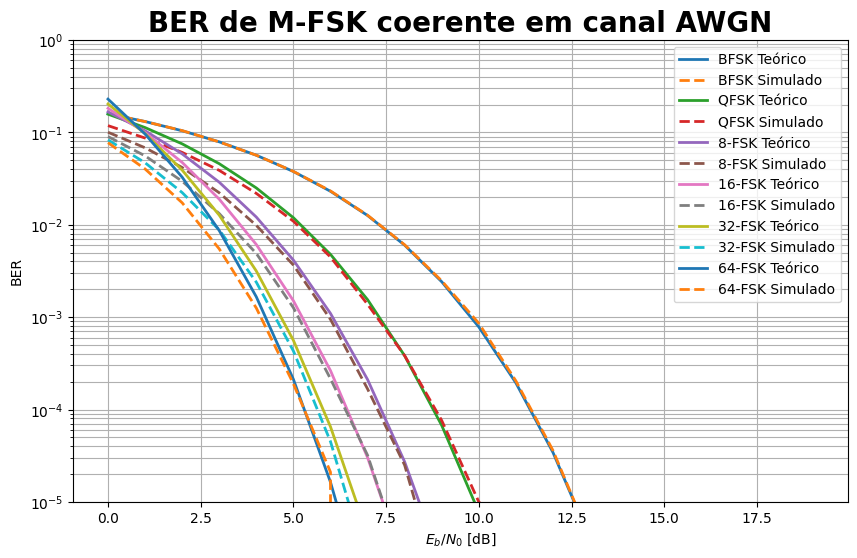

In [7]:
# ============================================================
#   Simulação de BER para M-FSK ortogonal coerente
#   em canal AWGN
#
#   Cada símbolo ocupa uma dimensão distinta no espaço
#   de sinais.
#
#   Para uma M-FSK ortogonal, o espaço de sinais possui
#   dimensão M.
#
#   Exemplo para 4-FSK:
#
#   s_0 = [sqrt(Es), 0,        0,        0       ]
#   s_1 = [0,        sqrt(Es), 0,        0       ]
#   s_2 = [0,        0,        sqrt(Es), 0       ]
#   s_3 = [0,        0,        0,        sqrt(Es)]
#
#   A detecção é realizada por máxima verossimilhança:
#   escolhe-se o símbolo com menor distância euclidiana.
# ============================================================


# -----------------------------
# Figura
# -----------------------------

plt.figure(figsize=(10, 6))


# -----------------------------
# Loop para cada M-FSK
# -----------------------------

for M in M_list:

    # Quantidade de bits transportados por símbolo
    k = int(np.log2(M))

    # Número de símbolos simulados
    N_symbols = N_bits // k

    # Ajuste para múltiplo inteiro de k
    N_bits_real = N_symbols * k

    # Vetores para armazenar as curvas
    ber_sim = np.zeros(itr)

    ber_theo = np.zeros(itr)

    # Nome utilizado no gráfico e no terminal
    modulation_name = nome_fsk(M)

    # ---------------------------------------------------------
    # 1) Geração dos bits de informação
    # ---------------------------------------------------------

    tx_bits = np.random.randint(0, 2, N_bits_real)

    # Agrupamento dos bits em símbolos de k bits
    tx_bits_grouped = tx_bits.reshape((N_symbols, k))

    # Conversão dos símbolos binários para decimal
    tx_decimal = bits_to_decimal(tx_bits_grouped)

    # ---------------------------------------------------------
    # 2) Constelação ortogonal M-FSK
    # ---------------------------------------------------------

    # Energia média por bit
    Eb = 1

    # Energia por símbolo:
    #
    # Es = k * Eb
    Es = k * Eb

    # A matriz identidade gera símbolos ortogonais.
    #
    # Cada linha representa um símbolo M-FSK possível.
    #
    # A multiplicação por sqrt(Es) garante que cada símbolo
    # tenha energia Es.
    constellation = (np.sqrt(Es) * np.eye(M))

    # Seleciona os símbolos correspondentes
    # aos grupos de bits transmitidos
    tx_symbols = constellation[
        tx_decimal
    ]

    # ---------------------------------------------------------
    # 3) Loop para cada valor de Eb/N0
    # ---------------------------------------------------------

    for n, EbN0dB in enumerate(EbN0dB_range):

        # Conversão de dB para escala linear
        EbN0 = 10 ** (EbN0dB / 10)

        # Cálculo da densidade espectral de potência do ruído
        N0 = Eb / EbN0

        # Desvio-padrão de cada componente real do AWGN
        noise_std = np.sqrt(N0 / 2)

        # O ruído possui uma componente independente
        # para cada uma das M dimensões
        noise = noise_std * np.random.randn(N_symbols, M)

        # Canal AWGN:
        #
        # x = s_i + n
        rx_symbols = tx_symbols + noise

        # -----------------------------------------------------
        # 4) Detector de máxima verossimilhança
        # -----------------------------------------------------
        #
        # O receptor calcula a distância euclidiana quadrática
        # entre o vetor recebido e cada símbolo possível.
        #
        # Em seguida, escolhe o símbolo mais próximo.

        distances = np.zeros((N_symbols, M))

        for i in range(M):

            distances[:, i] = np.sum((rx_symbols - constellation[i]) ** 2, axis=1)

        rx_decimal = np.argmin(distances, axis=1)

        # -----------------------------------------------------
        # 5) Conversão dos símbolos detectados para bits
        # -----------------------------------------------------

        rx_bits_grouped = decimal_to_bits(rx_decimal, k)

        rx_bits = rx_bits_grouped.reshape(-1)

        # -----------------------------------------------------
        # 6) BER simulada
        # -----------------------------------------------------

        bit_errors = np.sum(tx_bits != rx_bits)

        ber_sim[n] = (bit_errors / N_bits_real)

        # -----------------------------------------------------
        # 7) BER teórica aproximada
        # -----------------------------------------------------
        #
        # Probabilidade de erro de símbolo:
        #
        # Ps ≈ ((M - 1) * 0.5 * erfc(np.sqrt(k * EbN0 /2)))
        #
        # Para M-FSK ortogonal:
        #
        # BER = [M / (2*(M - 1))] * Ps

        Ps = ((M - 1) * 0.5 * erfc(np.sqrt(k * EbN0 /2)))

        ber_theo[n] = (M / (2 * (M - 1))) * Ps

        print(
            f"M = {M:2d} | "
            f"Eb/N0 = {EbN0dB:2d} dB | "
            f"BER_sim = {ber_sim[n]:.6e} | "
            f"BER_teo = {ber_theo[n]:.6e}"
        )

    # Armazena os resultados para a comparação final
    ber_fsk_theo_all[M] = ber_theo.copy()

    ber_fsk_sim_all[M] = ber_sim.copy()

    # ---------------------------------------------------------
    # 8) Plot das curvas
    # ---------------------------------------------------------

    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        linewidth=2,
        label=f"{modulation_name} Teórico"
    )

    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        "--",
        linewidth=2,
        label=f"{modulation_name} Simulado"
    )


# -----------------------------
# Configuração do gráfico
# -----------------------------

plt.grid(
    True,
    which="both"
)

plt.xlabel(
    "$E_b/N_0$ [dB]"
)

plt.ylabel(
    "BER"
)

plt.title(
    "BER de M-FSK coerente em canal AWGN",
    fontsize=20,
    fontweight="bold"
)

plt.legend()

plt.ylim(
    1e-5,
    1
)

plt.show()

## **Comparação dos resultados obtidos**

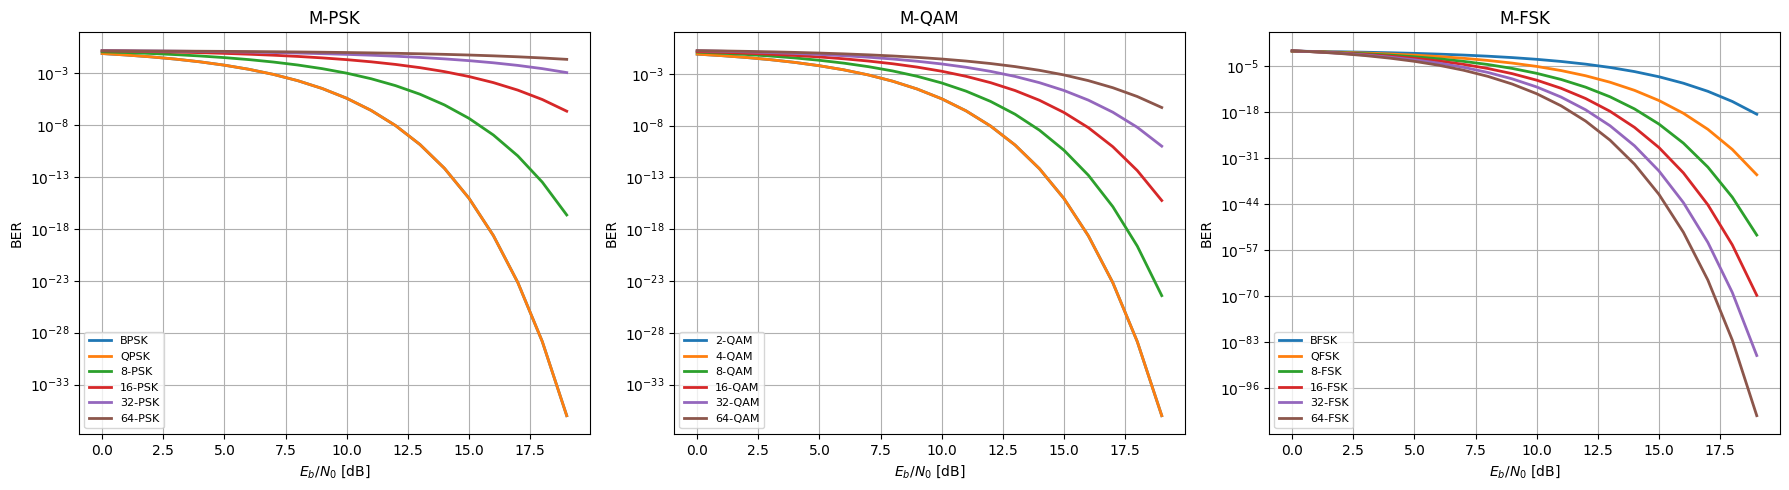

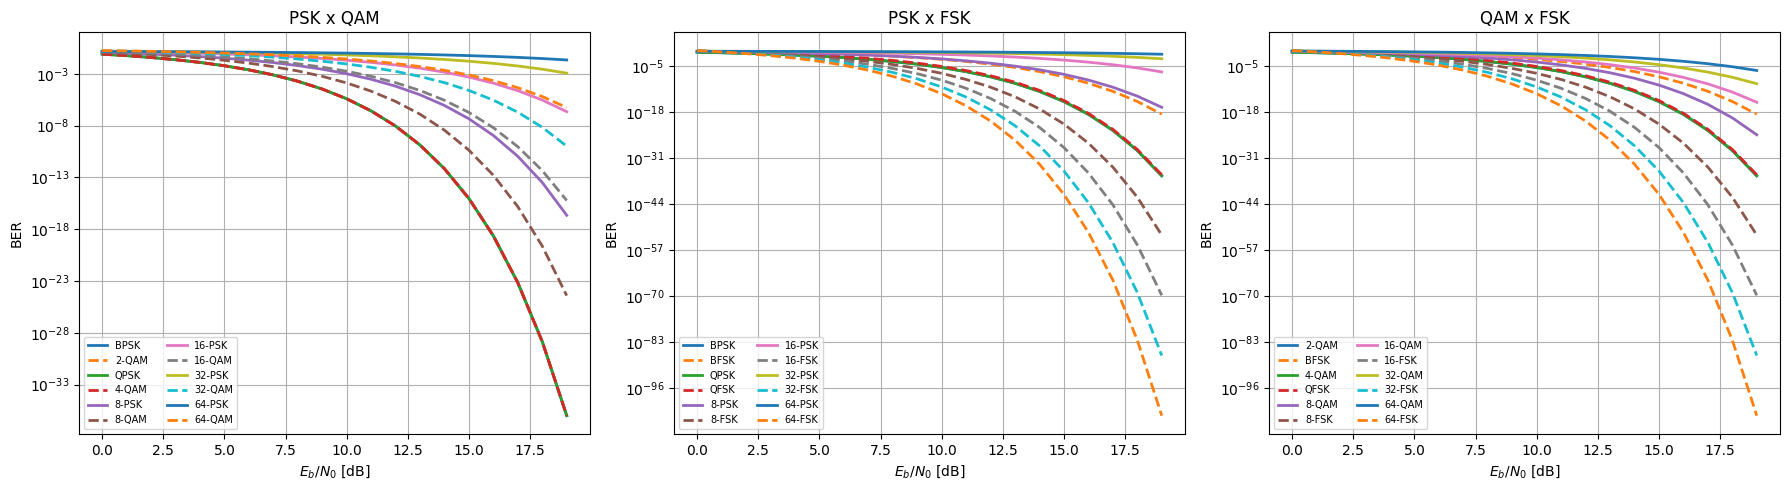

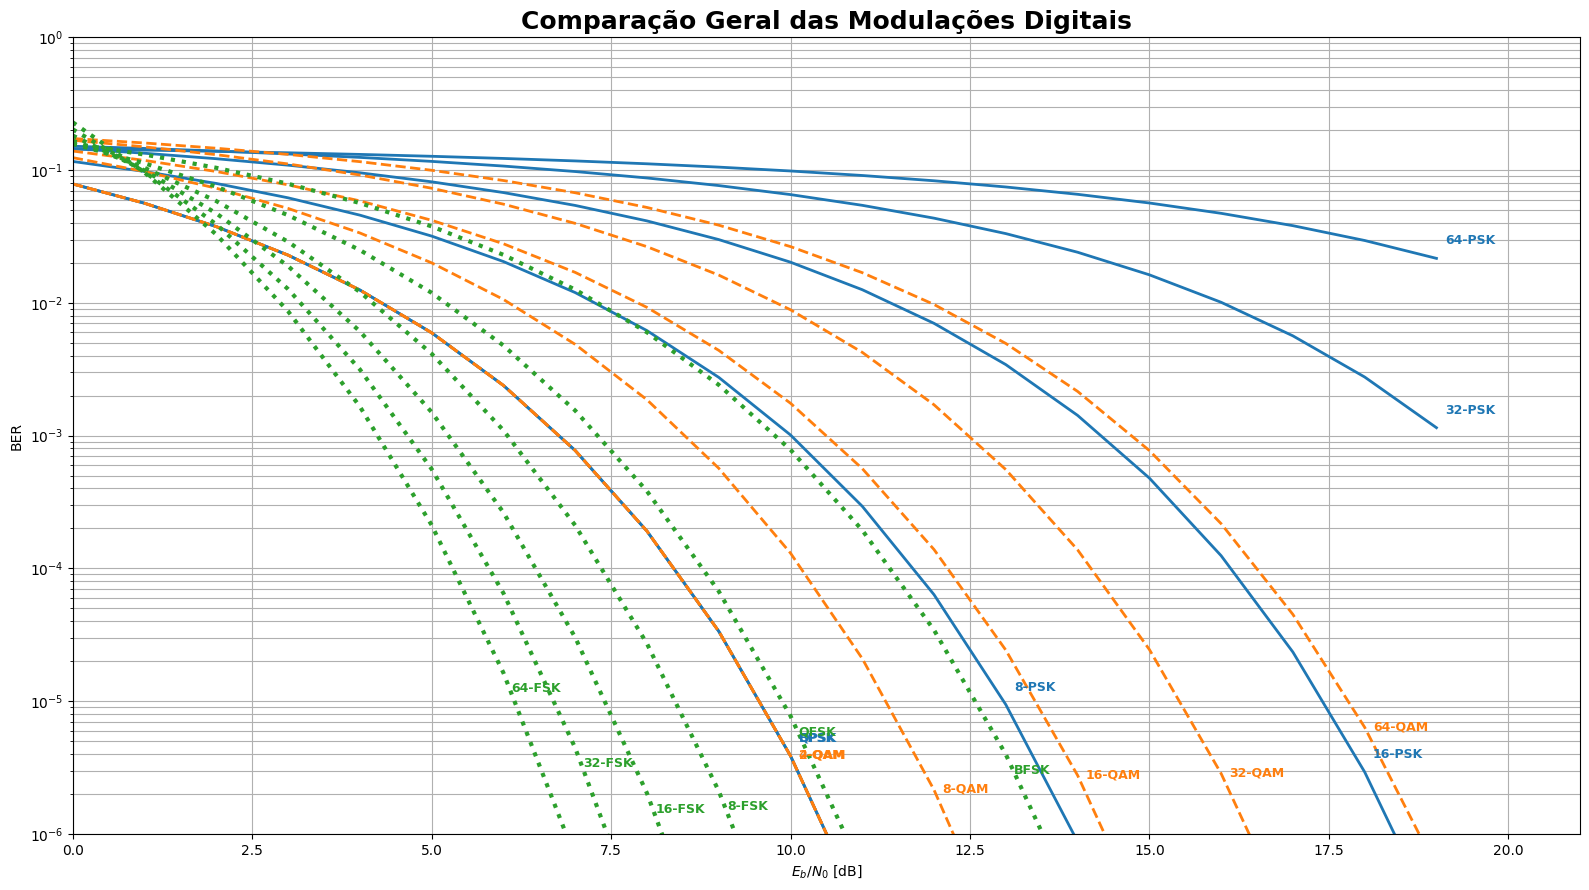

In [8]:
# ============================================================
#   Comparação das curvas teóricas de BER
#
#   Dicionários utilizados:
#
#   ber_psk_theo_all[M]
#   ber_qam_theo_all[M]
#   ber_fsk_theo_all[M]
# ============================================================


# ------------------------------------------------------------
# Ordens disponíveis em cada família
# ------------------------------------------------------------

M_list_psk = sorted(ber_psk_theo_all.keys())
M_list_qam = sorted(ber_qam_theo_all.keys())
M_list_fsk = sorted(ber_fsk_theo_all.keys())


# ============================================================
# Figura 1 - Gráficos individuais por família de modulação
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# ------------------------------------------------------------
# M-PSK
# ------------------------------------------------------------

for M in M_list_psk:

    ax[0].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        linewidth=2,
        label=nome_psk(M)
    )

ax[0].grid(True, which="both")
ax[0].set_title("M-PSK")
ax[0].set_xlabel("$E_b/N_0$ [dB]")
ax[0].set_ylabel("BER")
ax[0].legend(fontsize=8)


# ------------------------------------------------------------
# M-QAM
# ------------------------------------------------------------

for M in M_list_qam:

    ax[1].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        linewidth=2,
        label=nome_qam(M)
    )

ax[1].grid(True, which="both")
ax[1].set_title("M-QAM")
ax[1].set_xlabel("$E_b/N_0$ [dB]")
ax[1].set_ylabel("BER")
ax[1].legend(fontsize=8)


# ------------------------------------------------------------
# M-FSK
# ------------------------------------------------------------

for M in M_list_fsk:

    ax[2].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        linewidth=2,
        label=nome_fsk(M)
    )

ax[2].grid(True, which="both")
ax[2].set_title("M-FSK")
ax[2].set_xlabel("$E_b/N_0$ [dB]")
ax[2].set_ylabel("BER")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# Figura 2 - Comparações duas a duas
# ============================================================
#
# Linha contínua  -> primeira família
# Linha tracejada -> segunda família
#
# A interseção garante que sejam comparadas apenas as ordens
# existentes simultaneamente nas duas famílias.
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# ------------------------------------------------------------
# PSK x QAM
# ------------------------------------------------------------

M_psk_qam = sorted(
    set(M_list_psk) &
    set(M_list_qam)
)

for M in M_psk_qam:

    ax[0].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        "-",
        linewidth=2,
        label=nome_psk(M)
    )

    ax[0].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        "--",
        linewidth=2,
        label=nome_qam(M)
    )

ax[0].grid(True, which="both")
ax[0].set_title("PSK x QAM")
ax[0].set_xlabel("$E_b/N_0$ [dB]")
ax[0].set_ylabel("BER")
ax[0].legend(fontsize=7, ncol=2)


# ------------------------------------------------------------
# PSK x FSK
# ------------------------------------------------------------

M_psk_fsk = sorted(
    set(M_list_psk) &
    set(M_list_fsk)
)

for M in M_psk_fsk:

    ax[1].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        "-",
        linewidth=2,
        label=nome_psk(M)
    )

    ax[1].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        "--",
        linewidth=2,
        label=nome_fsk(M)
    )

ax[1].grid(True, which="both")
ax[1].set_title("PSK x FSK")
ax[1].set_xlabel("$E_b/N_0$ [dB]")
ax[1].set_ylabel("BER")
ax[1].legend(fontsize=7, ncol=2)


# ------------------------------------------------------------
# QAM x FSK
# ------------------------------------------------------------

M_qam_fsk = sorted(
    set(M_list_qam) &
    set(M_list_fsk)
)

for M in M_qam_fsk:

    ax[2].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        "-",
        linewidth=2,
        label=nome_qam(M)
    )

    ax[2].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        "--",
        linewidth=2,
        label=nome_fsk(M)
    )

ax[2].grid(True, which="both")
ax[2].set_title("QAM x FSK")
ax[2].set_xlabel("$E_b/N_0$ [dB]")
ax[2].set_ylabel("BER")
ax[2].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


# ============================================================
# Figura 3 - Comparação geral
# ============================================================
#
# Cores:
#
# azul    -> M-PSK
# laranja -> M-QAM
# verde   -> M-FSK
#
# Estilos:
#
# linha contínua  -> M-PSK
# linha tracejada -> M-QAM
# linha pontilhada -> M-FSK
#
# Não é utilizada legenda. O nome de cada modulação aparece
# diretamente sobre sua respectiva curva.
# ============================================================

plt.figure(figsize=(16, 9))

ax = plt.gca()

limite_inferior = 1e-6
limite_superior = 1


# ------------------------------------------------------------
# Função auxiliar para adicionar o nome sobre cada curva
# ------------------------------------------------------------

def adicionar_rotulo_na_curva(
    eixo,
    x,
    y,
    texto,
    cor,
    deslocamento_x=6,
    deslocamento_y=6
):
    """
    Adiciona um rótulo próximo ao último ponto visível da curva.
    """

    y = np.asarray(y)

    indices_validos = np.where(
        np.isfinite(y) &
        (y >= limite_inferior) &
        (y <= limite_superior)
    )[0]

    if len(indices_validos) == 0:
        return

    indice = indices_validos[-1]

    eixo.annotate(
        texto,
        xy=(x[indice], y[indice]),
        xytext=(deslocamento_x, deslocamento_y),
        textcoords="offset points",
        color=cor,
        fontsize=9,
        fontweight="bold"
    )


# ------------------------------------------------------------
# M-PSK
# ------------------------------------------------------------

for M in M_list_psk:

    curva_psk = ber_psk_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_psk,
        "-",
        color="tab:blue",
        linewidth=2
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_psk,
        texto=nome_psk(M),
        cor="tab:blue",
        deslocamento_y=10
    )


# ------------------------------------------------------------
# M-QAM
# ------------------------------------------------------------

for M in M_list_qam:

    curva_qam = ber_qam_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_qam,
        "--",
        color="tab:orange",
        linewidth=2
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_qam,
        texto=nome_qam(M),
        cor="tab:orange",
        deslocamento_y=-2
    )


# ------------------------------------------------------------
# M-FSK
# ------------------------------------------------------------

for M in M_list_fsk:

    curva_fsk = ber_fsk_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_fsk,
        ":",
        color="tab:green",
        linewidth=3
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_fsk,
        texto=nome_fsk(M),
        cor="tab:green",
        deslocamento_y=-14
    )


# ------------------------------------------------------------
# Configuração do gráfico
# ------------------------------------------------------------

ax.grid(True, which="both")

ax.set_xlabel(
    "$E_b/N_0$ [dB]"
)

ax.set_ylabel(
    "BER"
)

ax.set_title(
    "Comparação Geral das Modulações Digitais",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylim(
    limite_inferior,
    limite_superior
)

# Espaço adicional à direita para exibir os rótulos
ax.set_xlim(
    EbN0dB_range[0],
    EbN0dB_range[-1] + 2
)

plt.tight_layout()
plt.show()

## **Comparação entre as modulações M-PSK, M-QAM e M-FSK**

Os gráficos apresentam a taxa de erro de bit teórica, denominada BER (*Bit Error Rate*), em função da relação entre a energia média por bit e a densidade espectral de potência do ruído:

$$
\frac{E_b}{N_0}
$$

A análise considera um canal AWGN (*Additive White Gaussian Noise*) e detecção coerente. Quanto maior o valor de $E_b/N_0$, menor tende a ser a influência do ruído sobre o sinal recebido e, consequentemente, menor é a BER.

As curvas também permitem observar que o efeito causado pelo aumento do número de símbolos $M$ depende da família de modulação utilizada. Como cada símbolo transporta:

$$
k = \log_2(M)
$$

bits, aumentar $M$ permite transmitir mais bits em cada intervalo de símbolo. Entretanto, essa alteração pode melhorar ou degradar a robustez ao ruído, dependendo da forma como a constelação é construída.

---

### Modulação M-PSK

Na modulação M-PSK (*M-ary Phase Shift Keying*), todos os símbolos possuem a mesma amplitude e são diferenciados somente por suas fases.

A constelação é formada por $M$ pontos igualmente espaçados em uma circunferência. À medida que $M$ aumenta, a separação angular entre os símbolos vizinhos diminui:

$$
\Delta \theta = \frac{2\pi}{M}
$$

Consequentemente, os pontos ficam mais próximos entre si e o receptor se torna mais suscetível a erros causados pelo ruído.

Esse comportamento pode ser observado nas curvas azuis do gráfico geral: para um mesmo valor de $E_b/N_0$, a BER aumenta quando a ordem da modulação cresce. Portanto, uma 64-PSK apresenta desempenho inferior ao de uma 16-PSK, que, por sua vez, apresenta desempenho inferior ao de uma 8-PSK.

A M-PSK oferece boa eficiência espectral, mas modulações de ordem elevada exigem valores maiores de $E_b/N_0$ para alcançar uma BER reduzida.

---

### Modulação M-QAM

Na modulação M-QAM (*M-ary Quadrature Amplitude Modulation*), os símbolos são diferenciados por combinações de amplitude e fase. Geometricamente, cada símbolo é representado por duas componentes:

$$
\mathbf{s}_i = [I_i,Q_i]
$$

em que $I_i$ corresponde à componente em fase e $Q_i$ corresponde à componente em quadratura.

Assim como na M-PSK, o aumento de $M$ aproxima os pontos da constelação quando a energia média é mantida constante. Por isso, as curvas laranjas mostram que a BER também tende a aumentar com a ordem da modulação.

Entretanto, para um mesmo valor de $M$, a M-QAM normalmente apresenta desempenho superior ao da M-PSK, especialmente para ordens elevadas. Isso ocorre porque a distribuição dos símbolos no plano $I/Q$ permite aproveitar melhor o espaço de sinais, mantendo uma distância mínima maior entre os pontos.

Um caso importante é:

$$
4\text{-QAM} \equiv \text{QPSK}
$$

As duas modulações apresentam constelações geometricamente equivalentes, diferenciadas apenas por uma possível rotação. Por isso, suas curvas teóricas de BER coincidem.

Para valores como 16-QAM e 64-QAM, as constelações são quadradas. Para valores como 8-QAM e 32-QAM, podem ser utilizadas constelações não quadradas ou cruzadas. Nesses casos, não é possível garantir mapeamento Gray perfeito entre todos os símbolos vizinhos. Portanto, as curvas teóricas utilizadas para as constelações não quadradas devem ser interpretadas como aproximações ou referências de desempenho.

---

### Modulação M-FSK

Na modulação M-FSK (*M-ary Frequency Shift Keying*), cada símbolo é associado a uma frequência diferente. Para sinais ortogonais, cada símbolo pode ser representado em uma dimensão distinta do espaço de sinais.

Diferentemente do que ocorre na M-PSK e na M-QAM, aumentar $M$ na M-FSK pode melhorar a eficiência de potência. Isso é observado nas curvas verdes do gráfico: quanto maior o valor de $M$, menor tende a ser a BER para um mesmo valor de $E_b/N_0$.

Esse comportamento ocorre porque os sinais ortogonais mantêm uma separação adequada no espaço de sinais. Além disso, como cada símbolo transporta mais bits quando $M$ aumenta, a energia por símbolo também cresce:

$$
E_s = \log_2(M)E_b
$$

Assim, a M-FSK pode alcançar valores reduzidos de BER com menor relação $E_b/N_0$.

Entretanto, essa vantagem possui um custo importante: o aumento da ordem $M$ exige uma quantidade maior de frequências ortogonais e, consequentemente, uma largura de banda maior. Portanto, a M-FSK é adequada para sistemas com restrição de potência, mas pode ser pouco vantajosa em sistemas com largura de banda limitada.

---

### Comparação entre M-PSK e M-QAM

No gráfico comparativo entre M-PSK e M-QAM, observa-se que:

- Para $M=4$, as curvas são equivalentes, pois 4-QAM e QPSK possuem o mesmo desempenho.
- Para valores mais elevados de $M$, a M-QAM apresenta BER inferior à M-PSK.
- A diferença se torna mais significativa à medida que $M$ aumenta.

A M-QAM é geralmente mais eficiente que a M-PSK de mesma ordem em termos de potência, pois distribui os símbolos de forma mais eficiente no plano $I/Q$. Por esse motivo, modulações como 16-QAM e 64-QAM são amplamente utilizadas em sistemas que precisam transmitir taxas elevadas de dados dentro de uma largura de banda limitada.

---

### Comparação entre M-PSK e M-FSK

No gráfico comparativo entre M-PSK e M-FSK, observa-se um comportamento oposto quando $M$ aumenta:

- Na M-PSK, aumentar $M$ reduz a distância angular entre os símbolos e eleva a BER.
- Na M-FSK, aumentar $M$ melhora a eficiência de potência e reduz a BER.

Assim, a M-PSK é mais adequada quando a economia de largura de banda é prioritária. Já a M-FSK pode ser mais adequada quando o sistema possui maior disponibilidade de largura de banda e precisa operar com menor potência.

---

### Comparação entre M-QAM e M-FSK

A comparação entre M-QAM e M-FSK evidencia uma relação de compromisso entre eficiência espectral e eficiência de potência:

- A M-QAM utiliza a largura de banda de forma mais eficiente, permitindo transmitir mais bits por símbolo sem exigir múltiplas frequências ortogonais.
- A M-FSK apresenta maior robustez ao ruído para valores elevados de $M$, mas ocupa uma largura de banda consideravelmente maior.

Portanto, a escolha entre essas modulações depende das restrições do sistema:

| Modulação | Principal vantagem | Principal desvantagem |
|---|---|---|
| M-PSK | Estrutura simples e amplitude constante | Sensibilidade elevada ao ruído para valores altos de $M$ |
| M-QAM | Boa eficiência espectral e melhor desempenho que M-PSK de mesma ordem | Maior complexidade e sensibilidade a variações de amplitude |
| M-FSK | Boa eficiência de potência e elevada robustez ao ruído | Necessidade de maior largura de banda |

---

### Observação sobre as curvas teóricas

As expressões utilizadas para gerar os gráficos são aproximações teóricas. Em especial:

- A expressão da BER da M-PSK é mais adequada para valores elevados de $E_b/N_0$.
- A expressão da M-QAM quadrada considera mapeamento Gray.
- Para M-QAM não quadrada, a curva representa uma aproximação ou referência.
- A expressão da M-FSK coerente é obtida a partir de uma aproximação para a probabilidade de erro de símbolo baseada no limitante de união.

Por isso, podem existir pequenas diferenças entre as curvas teóricas e os resultados obtidos por simulação, principalmente para valores reduzidos de $E_b/N_0$.

Além disso, valores extremamente baixos de BER, como $10^{-20}$ ou $10^{-50}$, são úteis para comparação matemática, mas seriam difíceis de validar diretamente por simulação de Monte Carlo, pois exigiriam a transmissão de uma quantidade muito elevada de bits.